In [1]:
import geopandas as gpd
import pandas as pd


from shapely.ops import unary_union, linemerge
from shapely.geometry import Point, LineString, MultiLineString
from shapely.geometry import mapping


import networkx as nx


import folium
from folium import Map, GeoJson


import json
import mapillary as mly




### Berlin einlesen für Proof of concept

<Axes: >

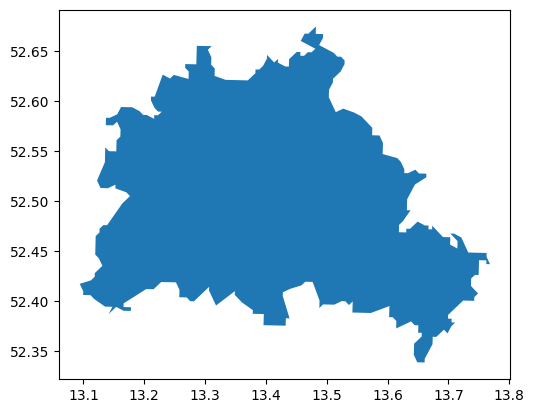

In [2]:
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
bland_fil=bland[bland["id"].isin(["DE-BE"])]
bland_fil.plot()

### netzwerk einlesen

In [3]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
highways=gpd.read_file("../preprocessing/processed_osm_files/processed_almostall_highways_germany_250528.geojson.gz")


In [4]:
# set defaults
highways.loc[(highways["maxspeed"].isna() | (highways["maxspeed"] == "None")) & (highways["maxspeed_type"] == "DE:urban"), "maxspeed"] = "50"
highways.loc[(highways["maxspeed"].isna() | (highways["maxspeed"] == "None")) & (highways["maxspeed_type"] == "DE:rural"), "maxspeed"] = "100"
highways

,osm_id,highway,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,geometry
0,92,residential,30,None,None,None,None,Eigenheimstraße,None,"LINESTRING (13.73698 51.01663, 13.73752 51.016..."
1,93,residential,30,None,None,None,None,Eigenheimberg,None,"LINESTRING (13.73939 51.01669, 13.73967 51.016..."
2,99,tertiary,None,None,None,None,None,None,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
3,100,secondary,100,None,None,None,None,None,None,"LINESTRING (11.33037 48.1801, 11.33032 48.1801..."
4,103,residential,5,None,None,None,None,Altmockritz,None,"LINESTRING (13.74127 51.01615, 13.74149 51.016..."
...,...,...,...,...,...,...,...,...,...,...
11045659,1390550454,service,None,None,None,None,None,None,None,"LINESTRING (13.56334 52.53415, 13.56334 52.534..."
11045660,1390550455,service,None,None,None,None,None,None,None,"LINESTRING (13.56304 52.53414, 13.56303 52.534..."
11045661,1390550456,service,None,None,None,None,None,None,None,"LINESTRING (13.56203 52.53407, 13.56204 52.534..."
11045662,1390550457,service,None,None,None,None,None,None,None,"LINESTRING (13.56165 52.53405, 13.56165 52.534..."


In [5]:
## nur Berlin
highways_in_bl = gpd.clip(highways, bland_fil)
highways_in_bl

,osm_id,highway,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,geometry
446316,24380018,residential,30,None,None,None,None,Liebknechtstraße,None,"LINESTRING (13.65769 52.33877, 13.65785 52.339..."
8849268,865871690,service,10,None,None,None,None,Wernsdorfer Straße,None,"LINESTRING (13.65925 52.33881, 13.65937 52.338..."
8559717,800638930,service,None,None,None,None,None,None,None,"LINESTRING (13.66077 52.33952, 13.66065 52.339..."
171179,10587008,unclassified,30,None,None,None,None,Moßkopfring,None,"LINESTRING (13.64705 52.34252, 13.64697 52.342..."
9385887,969836864,service,None,None,None,None,None,None,None,"LINESTRING (13.64681 52.34196, 13.64756 52.34185)"
...,...,...,...,...,...,...,...,...,...,...
6625124,389304639,track,None,None,None,None,None,None,None,"LINESTRING (13.47607 52.67116, 13.47587 52.671..."
8591380,806491145,track,None,None,None,None,None,None,None,"LINESTRING (13.47607 52.67116, 13.47616 52.671..."
4721567,197689751,track,None,None,None,None,None,None,None,"LINESTRING (13.48214 52.67267, 13.4821 52.6727..."
8907239,881562217,track,None,None,None,None,None,None,None,"LINESTRING (13.4821 52.67272, 13.48215 52.67274)"


<Axes: >

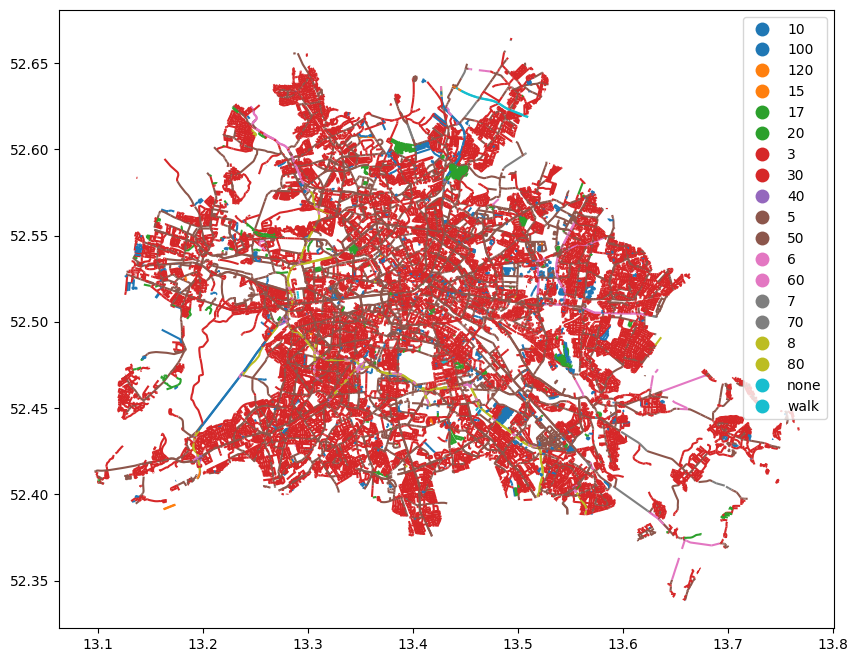

In [6]:
highways_in_bl.plot(column="maxspeed", legend=True, figsize=(10, 10))

<Axes: >

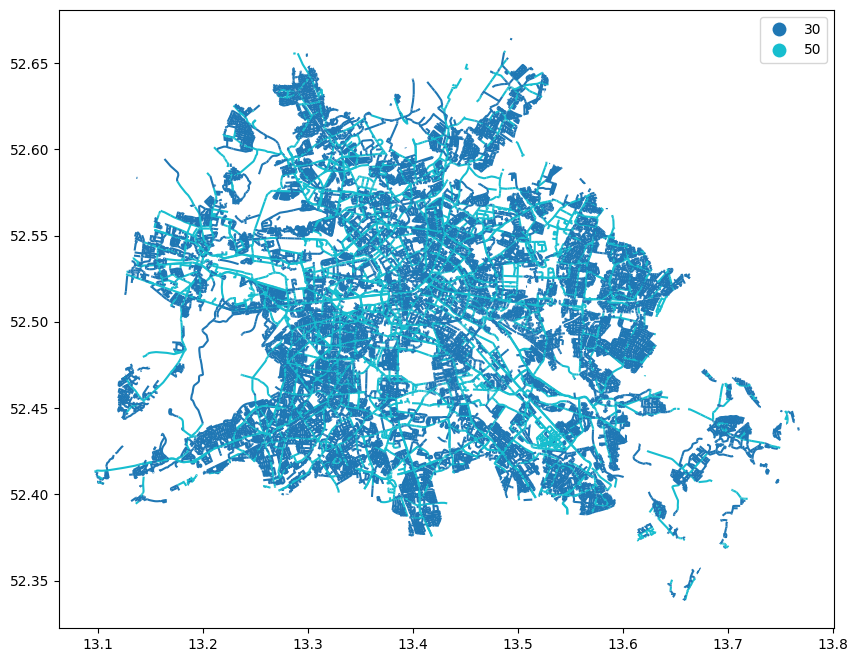

In [7]:
#nur 30 und 50 km/h

highways_in_bl_3050=highways_in_bl[highways_in_bl.maxspeed.isin(["30", "50"])].copy()
highways_in_bl_3050.plot(column="maxspeed", legend=True, figsize=(10, 10))

In [8]:
### schools einlesen

schools_gdf = gpd.read_file("../preprocessing/processed_osm_files/processed_schools_germany_250528.fgb")

schools_gdf

,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry
0,1938163084,None,kindergarten,None,points,None,POINT (13.73271 48.58014)
1,None,None,school,None,multipolygons,192729055,"MULTIPOLYGON (((13.66324 48.57875, 13.66286 48..."
2,None,None,school,None,multipolygons,192729054,"MULTIPOLYGON (((13.66328 48.57854, 13.6634 48...."
3,None,Gymnasium Untergriesbach,school,None,multipolygons,192729051,"MULTIPOLYGON (((13.66402 48.5784, 13.66296 48...."
4,None,None,school,None,multipolygons,192729052,"MULTIPOLYGON (((13.66342 48.57824, 13.6634 48...."
...,...,...,...,...,...,...,...
81242,None,Kita Altforweiler,kindergarten,None,multipolygons,161591153,"MULTIPOLYGON (((6.70334 49.27681, 6.70336 49.2..."
81243,None,Grundschule,school,None,multipolygons,252719088,"MULTIPOLYGON (((6.70501 49.27708, 6.70509 49.2..."
81244,None,Kita,kindergarten,None,multipolygons,1250395881,"MULTIPOLYGON (((6.69909 49.25215, 6.69792 49.2..."
81245,None,Grundschule St. Oranna,school,None,multipolygons,238048642,"MULTIPOLYGON (((6.68945 49.26161, 6.68984 49.2..."


In [9]:
schools_gdf["oid"] = schools_gdf.apply(
    lambda row: f"way/{int(row.osm_way_id)}" if pd.notnull(row.osm_way_id) else (
        f"node/{int(row.osm_id)}" if pd.notnull(row.osm_id) else None
    ),
    axis=1
)

In [10]:
schools_gdf_25832=schools_gdf.to_crs(25832)


In [11]:
# buffer all schools by 30m and set right crs
schools_gdf_25832_buffer=schools_gdf_25832.copy()
schools_gdf_25832_buffer["geometry"]=schools_gdf_25832.buffer(30)

In [12]:
#set right crs 
highways_in_bl_25832=highways_in_bl.to_crs(25832)

In [13]:
# Ensure both datasets have spatial indexes
highways_in_bl_25832.sindex
schools_gdf_25832_buffer.sindex

# Faster alternative using a spatial join (used to clip here)
highways_clipped = gpd.sjoin(
    highways_in_bl_25832, schools_gdf_25832_buffer, how="inner", predicate="intersects"
)#.drop(columns=["index_right","year"])  # Remove unnecessary index column (year is from network)

#accidents_clipped

In [14]:
highways_clipped

,osm_id_left,highway,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name_left,ref,geometry,index_right,osm_id_right,name_right,amenity,isced_level,source_layer,osm_way_id,oid
8125504,722677555,service,None,None,None,None,None,None,None,"LINESTRING (817284.38 5808975.632, 817283.808 ...",16450,3641077083,Kita Zwergenstadt,kindergarten,None,points,None,node/3641077083
4847263,205786896,service,None,None,None,None,None,None,None,"LINESTRING (819893.335 5812516.638, 819888.891...",16469,None,Kita Kleine Pfefferkörner,kindergarten,None,multipolygons,204862196,way/204862196
2555414,59546569,service,None,None,None,None,None,None,None,"LINESTRING (819898.441 5812532.227, 819899.632...",16469,None,Kita Kleine Pfefferkörner,kindergarten,None,multipolygons,204862196,way/204862196
8699955,827566286,service,None,None,None,None,None,None,None,"LINESTRING (819854.452 5812522.712, 819852.875...",16469,None,Kita Kleine Pfefferkörner,kindergarten,None,multipolygons,204862196,way/204862196
8931951,886117875,tertiary,50,30 @ (06:00-18:00),None,None,None,Dorfstraße,L 301,"LINESTRING (819771.068 5812526.804, 819774.948...",16469,None,Kita Kleine Pfefferkörner,kindergarten,None,multipolygons,204862196,way/204862196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10569829,1271235780,service,None,None,None,None,None,None,None,"LINESTRING (803650.32 5843007.781, 803650.722 ...",20883,11044699459,Kleine Glückspilze,kindergarten,None,points,None,node/11044699459
7876322,665905353,service,None,None,None,None,None,None,None,"LINESTRING (803614.551 5843019.317, 803625.609...",20883,11044699459,Kleine Glückspilze,kindergarten,None,points,None,node/11044699459
9818618,1076497018,unclassified,50,None,None,None,None,Hobrechtsfelder Chaussee,None,"LINESTRING (803626.006 5843034.426, 803614.551...",20883,11044699459,Kleine Glückspilze,kindergarten,None,points,None,node/11044699459
8520967,793249318,service,None,None,None,None,None,None,None,"LINESTRING (803650.32 5843007.781, 803648.343 ...",20883,11044699459,Kleine Glückspilze,kindergarten,None,points,None,node/11044699459


In [15]:
filtered_links = highways_clipped[
    (highways_clipped["maxspeed"] == "50") &
    ~highways_clipped["maxspeed_conditional"].astype(str).str.startswith("30 @")
]
filtered_links

,osm_id_left,highway,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name_left,ref,geometry,index_right,osm_id_right,name_right,amenity,isced_level,source_layer,osm_way_id,oid
2658243,64826669,primary,50,None,None,None,None,Lichtenrader Damm,B 96,"LINESTRING (799795.405 5813717.486, 799801.961...",19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,way/49896029
2153089,43684175,service,50,None,None,None,None,None,None,"LINESTRING (799780.982 5813879.283, 799786.125...",19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,way/49896029
10056756,1135872979,primary,50,None,None,None,None,Lichtenrader Damm,B 96,"LINESTRING (799773.565 5813953.587, 799776.547...",19194,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,way/49896029
2658233,64824378,tertiary,50,None,None,None,None,Barnetstraße,None,"LINESTRING (799653.833 5813969.081, 799667.531...",19198,None,None,school,None,multipolygons,46248785,way/46248785
10508851,1252632004,tertiary,50,None,None,None,None,Barnetstraße,None,"LINESTRING (799532.309 5813987.783, 799513.287...",19197,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,node/6861804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9389023,970437507,residential,50,None,None,None,DE:urban,Haardtweg,None,"LINESTRING (783120.352 5830305.693, 783130.544...",19666,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,way/342384928
5642356,275251327,secondary,50,None,None,None,None,Falkenseer Chaussee,None,"LINESTRING (783083.482 5830314.843, 783120.352...",19666,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,way/342384928
1695998,35813431,secondary,50,None,None,None,None,Falkenseer Chaussee,None,"LINESTRING (782809.424 5830382.11, 782818.934 ...",19666,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,way/342384928
1695999,35813432,secondary,50,None,None,None,None,Falkenseer Chaussee,None,"LINESTRING (783130.544 5830315.652, 783026.341...",19666,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,way/342384928


In [16]:
merged_links_schools = pd.merge(
    filtered_links[["oid"]], 
    schools_gdf_25832_buffer, 
    how="inner", 
    on="oid"
)

# Show the merged result
merged_links_schools=merged_links_schools.drop_duplicates().copy()

In [17]:
import geopandas as gpd

merged_links_schools_gdf = gpd.GeoDataFrame(merged_links_schools, geometry="geometry", crs=schools_gdf_25832_buffer.crs)
merged_links_schools_gdf

,oid,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry
0,way/49896029,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,"POLYGON ((799800.477 5813883.682, 799800.873 5..."
3,way/46248785,None,None,school,None,multipolygons,46248785,"POLYGON ((799410.461 5814333.027, 799485.696 5..."
4,node/6861804,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,"POLYGON ((799580.522 5814090.252, 799575.793 5..."
7,way/300638299,None,Kita Mariä Himmelfahrt,kindergarten,None,multipolygons,300638299,"POLYGON ((780771.099 5819317.632, 780769.553 5..."
8,way/122548883,None,Kita Ritterfelddamm,kindergarten,None,multipolygons,122548883,"POLYGON ((781151.503 5819835.722, 781149.39 58..."
...,...,...,...,...,...,...,...,...
1292,node/268915830,268915830,EKT - Maxizwerge e.V.,kindergarten,None,points,None,"POLYGON ((790036.468 5840175.048, 790036.323 5..."
1293,way/928821752,None,Neues Gymnasium Glienicke,school,None,multipolygons,928821752,"POLYGON ((791868.64 5840486.951, 791877.492 58..."
1294,node/3093670,3093670,Evangelische Schule Berlin-Frohnau,school,None,multipolygons,None,"POLYGON ((789714.12 5839847.538, 789706.593 58..."
1295,way/342384928,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,"POLYGON ((783050.997 5830308.103, 783051.83 58..."


In [18]:
m = filtered_links.explore(color="red", style_kwds={"weight": 3}, tiles="CartoDB positron")
merged_links_schools_gdf.explore(m=m, color="blue", style_kwds={"fillOpacity": 0.2})

In [19]:
# Clip the filtered_links (highways) with the polygons in merged_links_schools_gdf
clipped_highways = gpd.overlay(filtered_links, merged_links_schools_gdf, how='intersection')

# Calculate the length of each clipped highway segment (in the current CRS, which is meters for EPSG:25832)
clipped_highways['length_m'] = clipped_highways.geometry.length

#clipped_highways[['geometry', 'length_m']]

In [20]:
# Calculate the total length per oid_1
lengths = clipped_highways.groupby("oid_1")["length_m"].sum()

# Add as new column to merged_links_schools_gdf, matching by oid
merged_links_schools_gdf["total_tempo50_highway_length_m"] = merged_links_schools_gdf["oid"].map(lengths)

In [21]:
merged_links_schools_gdf

,oid,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,total_tempo50_highway_length_m
0,way/49896029,None,Georg-Büchner-Gymnasium,school,None,multipolygons,49896029,"POLYGON ((799800.477 5813883.682, 799800.873 5...",189.360350
3,way/46248785,None,None,school,None,multipolygons,46248785,"POLYGON ((799410.461 5814333.027, 799485.696 5...",161.632398
4,node/6861804,6861804,Carl-Zeiss-Oberschule,school,"2,3",multipolygons,None,"POLYGON ((799580.522 5814090.252, 799575.793 5...",99.971400
7,way/300638299,None,Kita Mariä Himmelfahrt,kindergarten,None,multipolygons,300638299,"POLYGON ((780771.099 5819317.632, 780769.553 5...",93.694959
8,way/122548883,None,Kita Ritterfelddamm,kindergarten,None,multipolygons,122548883,"POLYGON ((781151.503 5819835.722, 781149.39 58...",10.519810
...,...,...,...,...,...,...,...,...,...
1292,node/268915830,268915830,EKT - Maxizwerge e.V.,kindergarten,None,points,None,"POLYGON ((790036.468 5840175.048, 790036.323 5...",51.372977
1293,way/928821752,None,Neues Gymnasium Glienicke,school,None,multipolygons,928821752,"POLYGON ((791868.64 5840486.951, 791877.492 58...",4.491481
1294,node/3093670,3093670,Evangelische Schule Berlin-Frohnau,school,None,multipolygons,None,"POLYGON ((789714.12 5839847.538, 789706.593 58...",10.775847
1295,way/342384928,None,Kita Remscheider Straße,kindergarten,None,multipolygons,342384928,"POLYGON ((783050.997 5830308.103, 783051.83 58...",169.710696


In [22]:
merged_links_schools_gdf_60m=merged_links_schools_gdf[merged_links_schools_gdf.total_tempo50_highway_length_m > 60].sort_values("total_tempo50_highway_length_m", ascending=False)#.head(10)

In [23]:
clipped_highways_60m=clipped_highways[clipped_highways.oid_1.isin(merged_links_schools_gdf_60m.oid)]


In [24]:
m = clipped_highways_60m.explore(color="red", style_kwds={"weight": 3}, tiles="CartoDB positron")
merged_links_schools_gdf_60m.explore(m=m, color="blue", style_kwds={"fillOpacity": 0.2})

In [25]:
#set right crs 
highways_25832=highways.to_crs(25832)

In [26]:
# Ensure both datasets have spatial indexes
highways_25832.sindex
schools_gdf_25832_buffer.sindex

# Faster alternative using a spatial join (used to clip here)
highways_clipped = gpd.sjoin(
    highways_25832, schools_gdf_25832_buffer, how="inner", predicate="intersects"
)#.drop(columns=["index_right","year"])  # Remove unnecessary index column (year is from network)


In [27]:
#highways_clipped

In [28]:
filtered_links = highways_clipped[
    (highways_clipped["maxspeed"] == "50") &
    ~highways_clipped["maxspeed_conditional"].astype(str).str.startswith("30 @")
]
filtered_links

,osm_id_left,highway,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name_left,ref,geometry,index_right,osm_id_right,name_right,amenity,isced_level,source_layer,osm_way_id,oid
5,104,unclassified,50,None,None,None,None,Münzmeisterstraße,None,"LINESTRING (832455.092 5663161.286, 832453.819...",14190,16644961,70. Grundschule „An der Südhöhe“,school,None,multipolygons,None,node/16644961
19,123,tertiary,50,None,None,None,None,Ackermannstraße,None,"LINESTRING (832886.302 5664175.097, 832884.736...",14196,None,Adolph-Kolping-Schule Dresden,school,None,multipolygons,284217468,way/284217468
19,123,tertiary,50,None,None,None,None,Ackermannstraße,None,"LINESTRING (832886.302 5664175.097, 832884.736...",14197,None,Berufliches Schulzentrum für Elektrotechnik Dr...,school,None,multipolygons,23373229,way/23373229
47,295111,tertiary,50,None,None,None,sign,Weberplatz,None,"LINESTRING (832830.043 5664005.935, 832831.483...",14196,None,Adolph-Kolping-Schule Dresden,school,None,multipolygons,284217468,way/284217468
153,1846730,tertiary,50,None,None,None,None,Büsnauer Straße,None,"LINESTRING (506133.361 5399974.789, 506135.016...",71818,None,Katholischer Kindergarten Büsnau,kindergarten,None,multipolygons,111803038,way/111803038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11042523,1389760257,secondary,50,None,None,None,None,Kirburger Straße,L 294,"LINESTRING (425991.237 5612439.796, 425986.209...",56866,None,Marie Curie Realschule plus,school,None,multipolygons,233789120,way/233789120
11042524,1389760258,secondary,50,None,None,None,None,Kirburger Straße,L 294,"LINESTRING (425993.204 5612457.418, 425991.237...",56866,None,Marie Curie Realschule plus,school,None,multipolygons,233789120,way/233789120
11042697,1389817701,residential,50,None,None,None,None,Alte Dorfstraße,None,"LINESTRING (499348.935 6009783.828, 499351.568...",39287,7156997569,Kindertagesstätte Wolkenschloss,kindergarten,None,points,None,node/7156997569
11043559,1389999666,primary,50,None,None,None,None,Südring,None,"LINESTRING (704541.392 5997032.046, 704550.967...",22421,None,Innerstädtisches Gymnasium,school,None,multipolygons,402355834,way/402355834


In [29]:
merged_links_schools = pd.merge(
    filtered_links[["oid"]], 
    schools_gdf_25832_buffer, 
    how="inner", 
    on="oid"
)

# Show the merged result
merged_links_schools=merged_links_schools.drop_duplicates().copy()

In [30]:
merged_links_schools_gdf = gpd.GeoDataFrame(merged_links_schools, geometry="geometry", crs=schools_gdf_25832_buffer.crs)
merged_links_schools_gdf

,oid,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry
0,node/16644961,16644961,70. Grundschule „An der Südhöhe“,school,None,multipolygons,None,"POLYGON ((832288.109 5662724.052, 832289.081 5..."
1,way/284217468,None,Adolph-Kolping-Schule Dresden,school,None,multipolygons,284217468,"POLYGON ((832801.375 5663815.497, 832812.176 5..."
2,way/23373229,None,Berufliches Schulzentrum für Elektrotechnik Dr...,school,None,multipolygons,23373229,"POLYGON ((832727.978 5664394.629, 832728.918 5..."
4,way/111803038,None,Katholischer Kindergarten Büsnau,kindergarten,None,multipolygons,111803038,"POLYGON ((506122.17 5399946.928, 506121.827 53..."
5,way/32707370,None,Grundschule am Schubinweg,school,None,multipolygons,32707370,"POLYGON ((678550.443 5339127.498, 678559.278 5..."
...,...,...,...,...,...,...,...,...
37034,way/1133774151,None,Freie Waldorfschule Stade,school,None,multipolygons,1133774151,"POLYGON ((532732.202 5936154.263, 532729.261 5..."
37060,way/16588365,None,Grundschule Groß-Buchholzer-Kirchweg,school,1,multipolygons,16588365,"POLYGON ((554646.429 5805925.851, 554645.419 5..."
37082,way/832910948,None,None,school,None,multipolygons,832910948,"POLYGON ((723325.425 5754157.128, 723325.376 5..."
37111,way/172411817,None,Gymnasium Trossingen,school,None,multipolygons,172411817,"POLYGON ((472223.509 5325200.386, 472221.748 5..."


<Axes: >

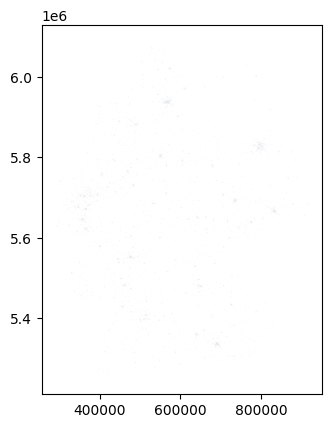

In [31]:
merged_links_schools_gdf.plot()

In [32]:
# Clip the filtered_links (highways) with the polygons in merged_links_schools_gdf
clipped_highways = gpd.overlay(filtered_links, merged_links_schools_gdf, how='intersection')

# Calculate the length of each clipped highway segment (in the current CRS, which is meters for EPSG:25832)
clipped_highways['length_m'] = clipped_highways.geometry.length

#clipped_highways[['geometry', 'length_m']]
# Calculate the total length per oid_1
lengths = clipped_highways.groupby("oid_1")["length_m"].sum()

# Add as new column to merged_links_schools_gdf, matching by oid
merged_links_schools_gdf["total_tempo50_highway_length_m"] = merged_links_schools_gdf["oid"].map(lengths)
merged_links_schools_gdf
merged_links_schools_gdf_60m=merged_links_schools_gdf[merged_links_schools_gdf.total_tempo50_highway_length_m > 60].sort_values("total_tempo50_highway_length_m", ascending=False)#.head(10)


In [33]:
merged_links_schools_gdf_60m

,oid,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,total_tempo50_highway_length_m
1258,way/38811140,None,Max-Planck-Schule,school,2;3,multipolygons,38811140,"POLYGON ((458717.94 5537714.143, 458734.347 55...",1804.759655
1567,way/141768337,None,Freie Waldorfschule,school,None,multipolygons,141768337,"POLYGON ((520655.246 5358791.749, 520652.822 5...",1707.631676
6035,way/141768342,None,Schulzentrum Freibühlschule,school,None,multipolygons,141768342,"POLYGON ((520651.261 5359004.754, 520651.402 5...",1569.434297
1946,way/968224521,None,Schule am Barnet-Licht-Platz - Oberschule der ...,school,None,multipolygons,968224521,"POLYGON ((737166.811 5691140.411, 737164.465 5...",1500.092010
2469,way/55679525,None,Staatliches Berufsbildungszentrum (BBZ),school,None,multipolygons,55679525,"POLYGON ((587331.336 5314667.511, 587363.031 5...",1458.520897
...,...,...,...,...,...,...,...,...,...
11806,way/926201295,None,None,kindergarten,None,multipolygons,926201295,"POLYGON ((568795.509 5511234.617, 568798.576 5...",60.140870
846,way/656281952,None,Kita Zum Kuckuck,kindergarten,None,multipolygons,656281952,"POLYGON ((409918.675 5316389.393, 409919.03 53...",60.124602
19363,way/662693629,None,Kindertagesstätte Sonnenkäfer,kindergarten,None,multipolygons,662693629,"POLYGON ((811930.884 5648010.602, 811924.963 5...",60.122132
32926,node/2292646676,2292646676,None,kindergarten,None,points,None,"POLYGON ((591522.399 5777128.374, 591522.255 5...",60.069841


<Axes: >

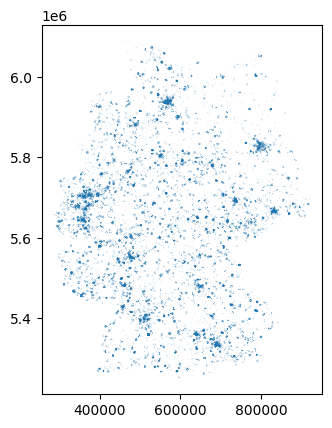

In [34]:
clipped_highways_60m=clipped_highways[clipped_highways.oid_1.isin(merged_links_schools_gdf_60m.oid)]
clipped_highways_60m.plot()

In [40]:
clipped_highways_60m[:10].explore(color="red", style_kwds={"weight": 3}, tiles="CartoDB positron")


In [41]:
clipped_highways_60m_dissolved = clipped_highways_60m.dissolve(by="oid_1")
clipped_highways_60m_dissolved=clipped_highways_60m_dissolved.reset_index()

clipped_highways_60m_dissolved=clipped_highways_60m_dissolved[["geometry","oid_1"]]

In [42]:
clipped_highways_60m_dissolved

,geometry,oid_1
0,"MULTILINESTRING ((356291.638 5454299.284, 3562...",node/10008262672
1,"MULTILINESTRING ((476131.094 5415311.159, 4761...",node/1004622378
2,"MULTILINESTRING ((690660 5338527.152, 690659.0...",node/10087831115
3,"MULTILINESTRING ((473251.792 5551334.085, 4732...",node/10093671966
4,"MULTILINESTRING ((382651.844 5616368.395, 3826...",node/1010644003
...,...,...
10809,"MULTILINESTRING ((757961.672 5611096.424, 7579...",way/999034846
10810,"MULTILINESTRING ((567729.692 5939874.879, 5677...",way/999208654
10811,"MULTILINESTRING ((502073.274 5354375.775, 5020...",way/999242299
10812,"LINESTRING (515540.016 5872811.76, 515526.636 ...",way/999483254


In [43]:
sc6_poly=merged_links_schools_gdf_60m.copy()
sc6_poly=sc6_poly.to_crs(4326)

In [44]:
sc6_poly.to_file("scenario6_tempo50_schulen_30mbuffer_polys.fgb", driver="FlatGeobuf")

In [45]:
sc6_centroids = sc6_poly.copy()
sc6_centroids=sc6_centroids.to_crs(25832)
sc6_centroids["geometry"] = sc6_centroids.geometry.centroid
sc6_centroids=sc6_centroids.to_crs(4326)

sc6_centroids

,oid,osm_id,name,amenity,isced_level,source_layer,osm_way_id,geometry,total_tempo50_highway_length_m
1258,way/38811140,None,Max-Planck-Schule,school,2;3,multipolygons,38811140,POINT (8.42533 49.98971),1804.759655
1567,way/141768337,None,Freie Waldorfschule,school,None,multipolygons,141768337,POINT (9.28035 48.38208),1707.631676
6035,way/141768342,None,Schulzentrum Freibühlschule,school,None,multipolygons,141768342,POINT (9.28079 48.38364),1569.434297
1946,way/968224521,None,Schule am Barnet-Licht-Platz - Oberschule der ...,school,None,multipolygons,968224521,POINT (12.40361 51.32293),1500.092010
2469,way/55679525,None,Staatliches Berufsbildungszentrum (BBZ),school,None,multipolygons,55679525,POINT (10.1707 47.97664),1458.520897
...,...,...,...,...,...,...,...,...,...
11806,way/926201295,None,None,kindergarten,None,multipolygons,926201295,POINT (9.95517 49.74918),60.140870
846,way/656281952,None,Kita Zum Kuckuck,kindergarten,None,multipolygons,656281952,POINT (7.79302 47.99433),60.124602
19363,way/662693629,None,Kindertagesstätte Sonnenkäfer,kindergarten,None,multipolygons,662693629,POINT (13.43758 50.89914),60.122132
32926,node/2292646676,2292646676,None,kindergarten,None,points,None,POINT (10.33684 52.13709),60.069841


In [46]:
sc6_centroids.to_file("scenario6_tempo50_schulen_30mbuffer_points.fgb", driver="FlatGeobuf")

In [50]:

sc6_buffered_links=clipped_highways_60m_dissolved.copy()
sc6_buffered_links.geometry = sc6_buffered_links.geometry.buffer(10)

sc6_buffered_links=sc6_buffered_links.to_crs(4326)

<Axes: >

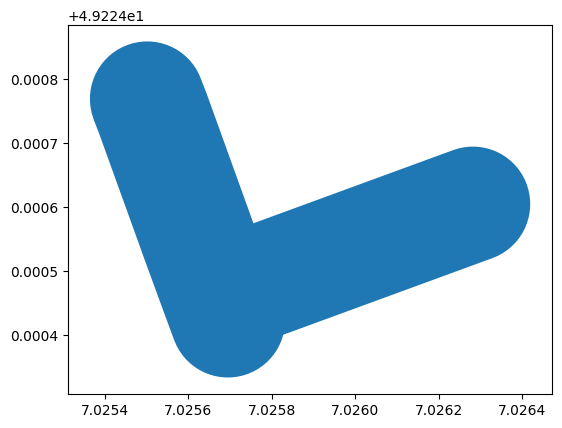

In [52]:
sc6_buffered_links[:1].plot()

In [53]:
sc6_buffered_links.to_file("scenario6_tempo50_schulen_30mbuffer_poly_links.fgb", driver="FlatGeobuf")

In [54]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, polys2_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"
    tmp_polys2 = "tmp_polys2.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys2,
        f"--layer={layer_name}-polys2",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys2_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys, tmp_polys2
    ], check=True)

    print("✅ Combined PMTiles created")


In [55]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario6_tempo50_schulen_30mbuffer_points.fgb",
    polys_fgb="scenario6_tempo50_schulen_30mbuffer_polys.fgb",
    polys2_fgb="scenario6_tempo50_schulen_30mbuffer_poly_links.fgb",
    output_pmtiles="scenario6_tempo50_30mbuffer_schulen.pmtiles",
    layer_name="scenario6"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
10814 features, 578872 bytes of geometry and attributes, 738220 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8748/5691  
detected indexed FlatGeobuf: assigning feature IDs by sequence
10814 features, 3629981 bytes of geometry and attributes, 738219 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17021/11148  
detected indexed FlatGeobuf: assigning feature IDs by sequence
10814 features, 4522765 bytes of geometry and attributes, 163445 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17220/11085  2/2123/1363  


✅ Combined PMTiles created
